# 02 – Volatility analysis

A short exploratory look at the realized-volatility series before forecasting models.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "../data/spy_daily_realized_volatility.csv",
    parse_dates=["date"],
)

df.head()

,date,realized_variance,realized_volatility,realized_volatility_percent,log_realized_variance
0,2024-10-04,0.000050,0.007089,0.708885,-9.898466
1,2024-10-07,0.000023,0.004801,0.480091,-10.677898
2,2024-10-08,0.000016,0.004034,0.403412,-11.025935
3,2024-10-09,0.000015,0.003849,0.384887,-11.119952
4,2024-10-10,0.000017,0.004162,0.416172,-10.963652


## Summary statistics

In [2]:
df[[
    "realized_variance",
    "realized_volatility_percent",
    "log_realized_variance",
]].describe()

,realized_variance,realized_volatility_percent,log_realized_variance
count,493.000000,493.000000,493.000000
mean,0.000063,0.646761,-10.347170
std,0.000221,0.463725,0.953558
min,0.000004,0.194616,-12.483791
25%,0.000016,0.394526,-11.070479
50%,0.000028,0.524865,-10.499568
75%,0.000062,0.790374,-9.680840
max,0.004133,6.428590,-5.488830


In [3]:
df.nlargest(
    10, "realized_volatility_percent"
)[["date", "realized_volatility_percent"]]

,date,realized_volatility_percent
123,2025-04-07,6.428590
125,2025-04-09,4.537769
126,2025-04-10,3.424957
124,2025-04-08,2.890737
122,2025-04-04,2.856732
127,2025-04-11,1.899245
104,2025-03-11,1.711649
414,2026-06-09,1.596035
102,2025-03-07,1.594632
416,2026-06-11,1.448078


## Time series

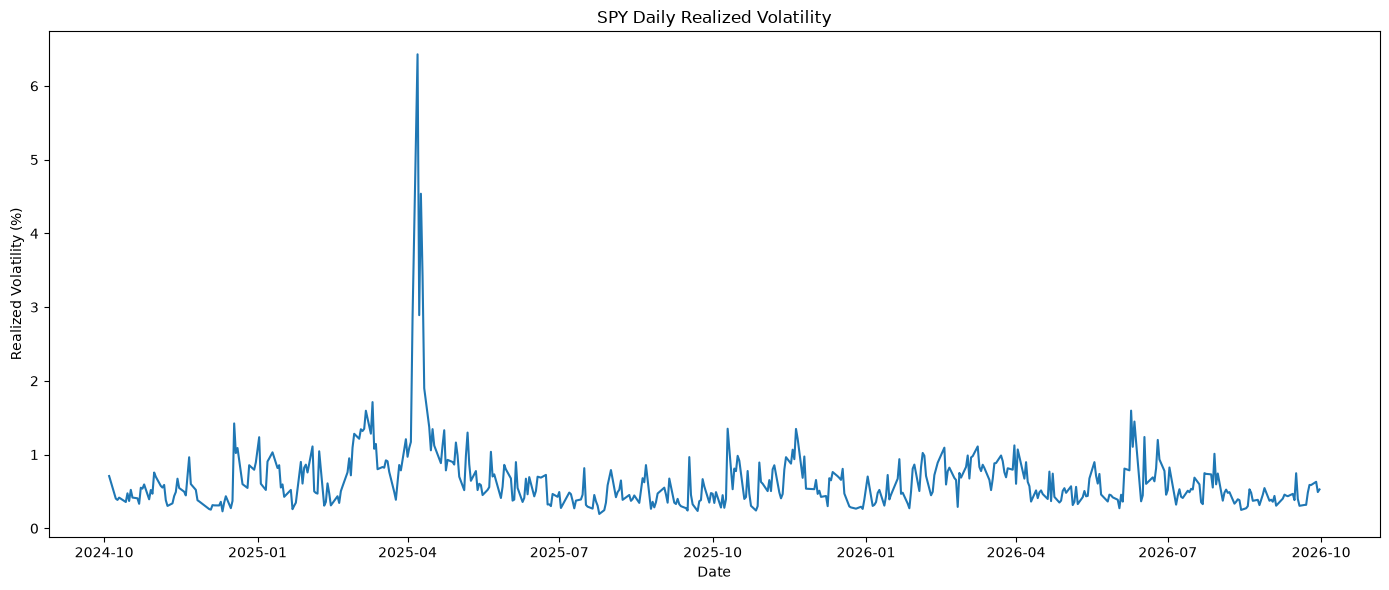

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["realized_volatility_percent"])
plt.title("SPY Daily Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Realized Volatility (%)")
plt.tight_layout()
plt.show()

## Distribution

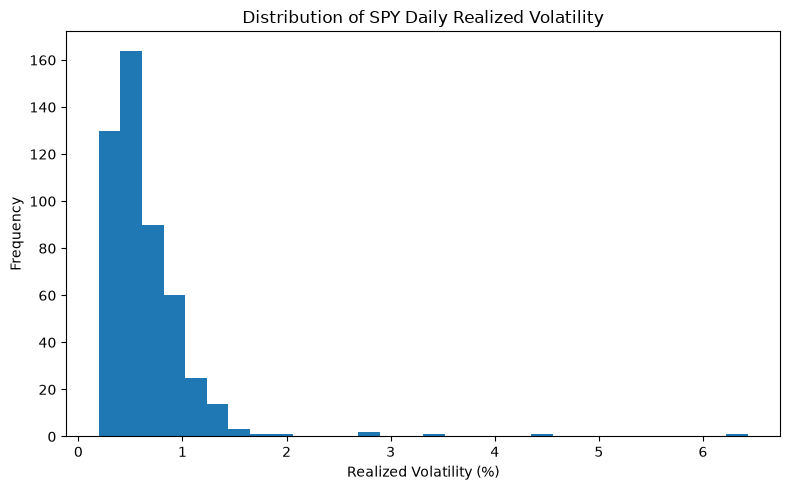

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["realized_volatility_percent"], bins=30)
plt.title("Distribution of SPY Daily Realized Volatility")
plt.xlabel("Realized Volatility (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

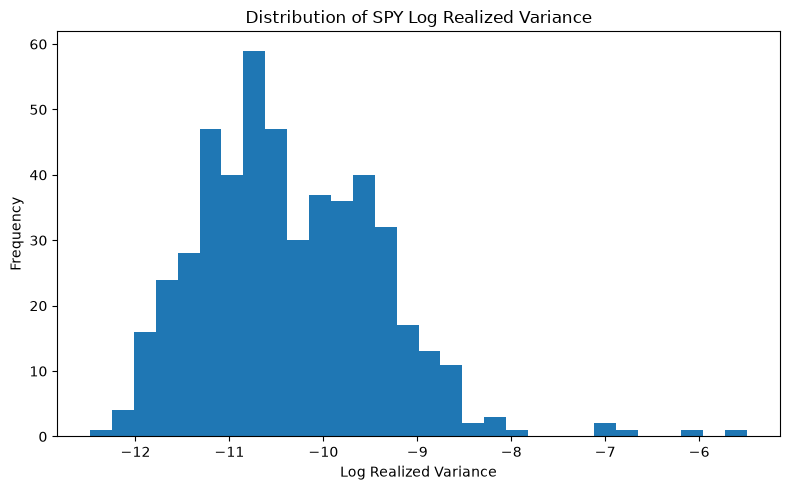

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_realized_variance"], bins=30)
plt.title("Distribution of SPY Log Realized Variance")
plt.xlabel("Log Realized Variance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
print("RV skewness:", round(df["realized_variance"].skew(), 3))
print("Log-RV skewness:", round(df["log_realized_variance"].skew(), 3))

RV skewness: 14.621
Log-RV skewness: 0.776


## Persistence

In [8]:
for lag in [1, 5, 22]:
    corr = df["log_realized_variance"].autocorr(lag=lag)
    print(f"Lag {lag}: {corr:.3f}")

Lag 1: 0.687
Lag 5: 0.402
Lag 22: 0.190


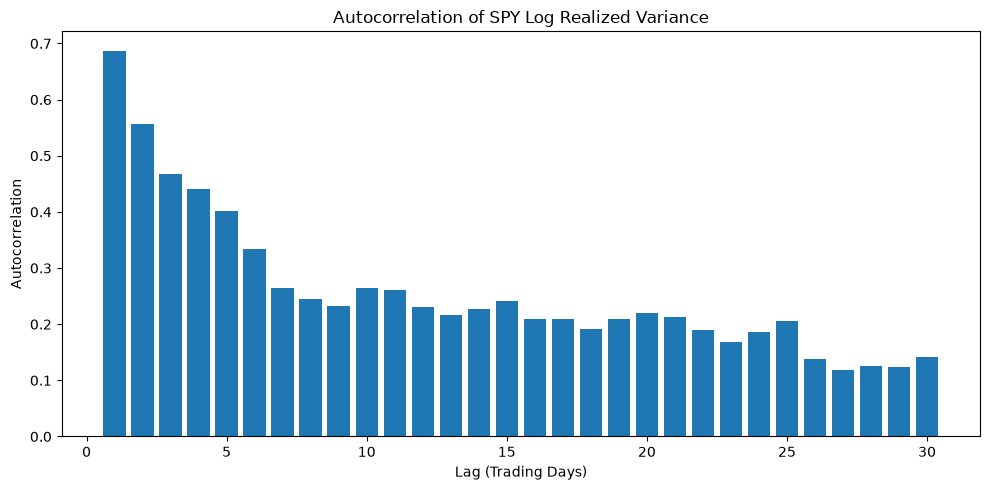

In [9]:
lags = range(1, 31)
autocorr = [df["log_realized_variance"].autocorr(lag=i) for i in lags]

plt.figure(figsize=(10, 5))
plt.bar(lags, autocorr)
plt.title("Autocorrelation of SPY Log Realized Variance")
plt.xlabel("Lag (Trading Days)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()